# 🫀 Heart disease classification — a step-by-step walkthrough

**Goal.** Work through a realistic machine learning project end to end: reading raw
data, preprocessing, training several models, tuning hyperparameters, and —
most importantly — **evaluating the result honestly**.

**What makes this notebook unusual.** By the end we will discover that this dataset
contains *no predictive signal at all*. That is not a failure; it is the most
important result here, and being able to prove it is a skill every data
professional needs.

| Section | Topic |
|---|---|
| 1 | Loading the data and the `"None"` trap |
| 2 | Exploratory data analysis |
| 3 | Preprocessing with `Pipeline` |
| 4 | Train/test split and a baseline |
| 5 | Training and comparing 8 models |
| 6 | ROC curves and the confusion matrix |
| 7 | Hyperparameter tuning with `GridSearchCV` |
| 8 | The control experiment: shuffled labels |
| 9 | Conclusions and exercises |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# Find the data file whether the notebook runs from the repo root or notebooks/
here = Path.cwd()
DATA = next(
    p / "Dataset" / "heart_disease.csv"
    for p in (here, *here.parents)
    if (p / "Dataset" / "heart_disease.csv").exists()
)
print("Data:", DATA)

Data: /Users/ts00018/DataScience/heart-disease/Dataset/heart_disease.csv


---
## 1. Loading the data — and the first trap

Let us read the file the most ordinary way possible and look at the missing values.

In [2]:
df_wrong = pd.read_csv(DATA)
print("Missing values per column (default read):\n")
print((df_wrong.isna().sum().sort_values(ascending=False).head(5)))

Missing values per column (default read):

Alcohol Consumption    2586
Cholesterol Level        30
Sugar Consumption        30
Diabetes                 30
Age                      29
dtype: int64


`Alcohol Consumption` is missing **2,586 cells (25.9%)** — wildly out of line with
every other column, which is missing only about 25.

Open the data dictionary and you find this column has **four levels**: `None`,
`Low`, `Medium`, `High`.

The problem: `pandas` treats the string `"None"` as a **missing value** by default.
Let us verify that.

In [3]:
# Count directly in the raw file, bypassing pandas
import csv

with open(DATA, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

raw = pd.Series([r["Alcohol Consumption"] for r in rows]).value_counts(dropna=False)
print("Actual values in the CSV:\n")
print(raw)

Actual values in the CSV:

None      2554
Medium    2500
Low       2488
High      2426
            32
Name: count, dtype: int64


Exactly as suspected: **2,554 rows hold a perfectly valid `"None"`** — meaning
*does not drink*, a medically important group. Only 32 cells are genuinely missing.

The correct way to read it is to switch off pandas' default NA list.

In [4]:
df = pd.read_csv(DATA, keep_default_na=False, na_values=[""])

print("Alcohol Consumption, read correctly:")
print(df["Alcohol Consumption"].value_counts(dropna=False), "\n")
print(f"Genuinely missing: {df['Alcohol Consumption'].isna().sum()} cells "
      f"({df['Alcohol Consumption'].isna().mean():.2%})")

Alcohol Consumption, read correctly:
Alcohol Consumption
None      2554
Medium    2500
Low       2488
High      2426
NaN         32
Name: count, dtype: int64 

Genuinely missing: 32 cells (0.32%)


> ### 📌 Lesson 1
> **Always reconcile the data against the data dictionary before doing anything else.**
> Skip that step and we would have thrown away 25% of a valid column — or worse,
> imputed the median over 2,554 correct values.

---
## 2. Exploratory data analysis

In [5]:
TARGET = "Heart Disease Status"

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with at least one gap: {df.isna().any(axis=1).sum():,} "
      f"({df.isna().any(axis=1).mean():.1%})")
df.head()

Shape: 10,000 rows x 21 columns
Duplicate rows: 0
Rows with at least one gap: 500 (5.0%)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


### 2.1 The target is badly imbalanced

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64 

Disease rate: 20.0%


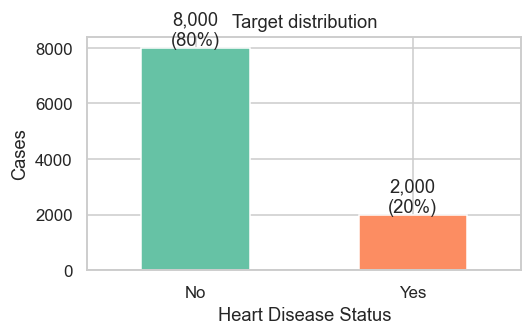

In [6]:
dist = df[TARGET].value_counts()
print(dist, "\n")
print(f"Disease rate: {(df[TARGET] == 'Yes').mean():.1%}")

fig, ax = plt.subplots(figsize=(5, 3.2))
dist.plot.bar(ax=ax, color=["#66c2a5", "#fc8d62"], rot=0)
ax.set_title("Target distribution")
ax.set_ylabel("Cases")
for i, v in enumerate(dist):
    ax.text(i, v + 100, f"{v:,}\n({v/len(df):.0%})", ha="center")
plt.tight_layout()
plt.show()

⚠️ **Only 20% of cases are positive.** The consequence matters enormously: a trivial
model that always answers *"no disease"* immediately scores **80% accuracy** without
learning anything.

Hold on to that **80%** — it will come back to haunt us.

### 2.2 Missing values

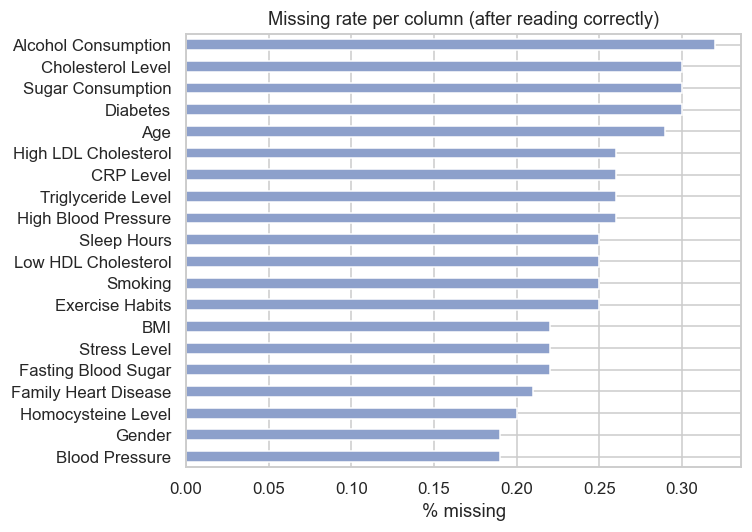

Worst column: 0.32%


In [7]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 5))
missing.plot.barh(ax=ax, color="#8da0cb")
ax.set_xlabel("% missing")
ax.set_title("Missing rate per column (after reading correctly)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Worst column: {missing.iloc[0]:.2f}%")

Every column is missing roughly 0.2-0.3%, fairly evenly — the signature of gaps
punched in at random. In total just 500 empty cells out of 200,000, affecting
**500 rows (5.0%)**.

Compare that with the wrong read in section 1: once `"None"` is swallowed as `NaN`,
the figure balloons to **2,933 rows (29.3%)** — nearly six times higher. One
data-loading mistake distorts the entire assessment of data quality.

> ### 📌 Lesson 2
> Do not reach for `dropna()` reflexively, and do not judge how much data is missing
> before you are certain you read it correctly. For scattered gaps like these,
> **impute** rather than drop rows.

### 2.3 Do the features relate to the disease at all?

This is the most important question in EDA. Let us look at the disease rate within
each group.

In [8]:
cat_cols = [c for c in df.columns
            if df[c].dtype == object and c != TARGET]

print(f"Base rate (overall disease rate): {(df[TARGET]=='Yes').mean():.1%}\n")
print(f"{'Feature':24s} {'Group':10s} {'Disease rate':>14s}")
print("-" * 52)
for col in cat_cols[:6]:
    rate = df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean())
    for group, v in rate.items():
        print(f"{col:24s} {str(group):10s} {v:13.1%}")
    print()

Base rate (overall disease rate): 20.0%

Feature                  Group        Disease rate
----------------------------------------------------
Gender                   Female             20.7%
Gender                   Male               19.4%

Exercise Habits          High               20.0%
Exercise Habits          Low                19.7%
Exercise Habits          Medium             20.4%

Smoking                  No                 19.9%
Smoking                  Yes                20.1%

Family Heart Disease     No                 20.2%
Family Heart Disease     Yes                19.7%

Diabetes                 No                 20.1%
Diabetes                 Yes                19.9%

High Blood Pressure      No                 19.9%
High Blood Pressure      Yes                20.1%



👀 **Read that table carefully.** Smokers have a 20.1% disease rate, non-smokers
19.9%. With a family history: 19.7%; without: 20.2% — *the wrong way round*
medically.

Every group hovers at exactly the 20% base rate. That is an early warning sign.

Let us try the numeric features with correlation coefficients.

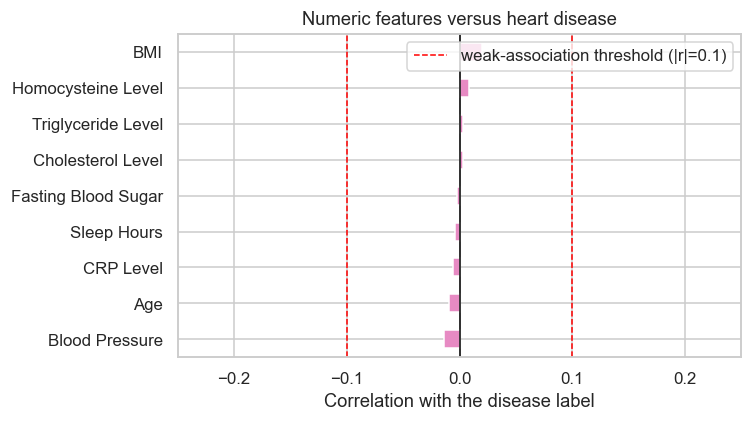

Blood Pressure        -0.0139
Age                   -0.0092
CRP Level             -0.0060
Sleep Hours           -0.0038
Fasting Blood Sugar   -0.0022
Cholesterol Level      0.0027
Triglyceride Level     0.0029
Homocysteine Level     0.0083
BMI                    0.0197
dtype: float64


In [9]:
num_cols = df.select_dtypes("number").columns.tolist()
y = (df[TARGET] == "Yes").astype(int)
corr = df[num_cols].corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
corr.plot.barh(ax=ax, color="#e78ac3")
ax.axvline(0, color="black", lw=1)
ax.axvline(0.1, color="red", ls="--", lw=1)
ax.axvline(-0.1, color="red", ls="--", lw=1, label="weak-association threshold (|r|=0.1)")
ax.set_xlim(-0.25, 0.25)
ax.set_xlabel("Correlation with the disease label")
ax.set_title("Numeric features versus heart disease")
ax.legend()
plt.tight_layout()
plt.show()

print(corr.round(4))

Every coefficient falls within **±0.02**, while even a *weak* association in real
medicine usually reaches |r| > 0.1 (the red lines).

We note the suspicion and carry on with the workflow anyway — a non-linear model can
sometimes catch a relationship that linear correlation misses.

---
## 3. Preprocessing with `Pipeline`

Models only eat **numbers**. We have to turn 20 raw columns into a numeric matrix,
and each *kind* of feature needs its own treatment.

In [10]:
NUMERIC_COLS = [
    "Age", "Blood Pressure", "Cholesterol Level", "BMI", "Sleep Hours",
    "Triglyceride Level", "Fasting Blood Sugar", "CRP Level", "Homocysteine Level",
]

# ORDINAL features: the order means something -> encode as increasing integers
ORDINAL_COLS = {
    "Exercise Habits":     ["Low", "Medium", "High"],
    "Alcohol Consumption": ["None", "Low", "Medium", "High"],
    "Stress Level":        ["Low", "Medium", "High"],
    "Sugar Consumption":   ["Low", "Medium", "High"],
}

# NOMINAL features: no order -> one-hot
NOMINAL_COLS = [
    "Gender", "Smoking", "Family Heart Disease", "Diabetes",
    "High Blood Pressure", "Low HDL Cholesterol", "High LDL Cholesterol",
]

FEATURE_COLS = NUMERIC_COLS + list(ORDINAL_COLS) + NOMINAL_COLS
print(f"{len(NUMERIC_COLS)} numeric + {len(ORDINAL_COLS)} ordinal "
      f"+ {len(NOMINAL_COLS)} nominal = {len(FEATURE_COLS)} input features")

9 numeric + 4 ordinal + 7 nominal = 20 input features


**Why separate ordinal from nominal?**

- `Low < Medium < High` has a real order, so mapping it to `0 < 1 < 2` preserves that
  information.
- `Male` / `Female` has no order. Assign 0/1 and a linear model will read it as
  *"Female is greater than Male"*, which is meaningless. Those need **one-hot**.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


def build_preprocessor(scale=True):
    """Impute -> encode -> scale. Pass scale=False for tree models."""
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))

    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), NUMERIC_COLS),
        ("ord", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OrdinalEncoder(categories=list(ORDINAL_COLS.values()))),
        ]), list(ORDINAL_COLS)),
        ("nom", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
        ]), NOMINAL_COLS),
    ])


prep = build_preprocessor()
print(prep)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Age', 'Blood Pressure', 'Cholesterol Level',
                                  'BMI', 'Sleep Hours', 'Triglyceride Level',
                                  'Fasting Blood Sugar', 'CRP Level',
                                  'Homocysteine Level']),
                                ('ord',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  Ordi...
                                                                              'Medium',
                                                   

> ### 📌 Lesson 3 — Data leakage
>
> The median used for imputation **must be computed on the training set only**.
>
> If you run `df.fillna(df.median())` over the whole dataset *before* splitting,
> information from the test set has leaked into training. Scores come out
> artificially good and the model collapses on real data.
>
> **The fix: wrap every step in a `Pipeline`.** `sklearn` will then `fit` only on
> each fold's training portion, automatically.

---
## 4. Train/test split and a baseline

In [12]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = (df[TARGET] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
    stratify=y,   # preserve the 80/20 balance in both sets
)

print(f"Train: {X_train.shape[0]:,} rows, disease rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]:,} rows, disease rate {y_test.mean():.1%}")

# Peek at the matrix after preprocessing
A = prep.fit_transform(X_train)
print(f"\nAfter preprocessing: {X_train.shape} -> {A.shape}")
print("No gaps left:", not np.isnan(A).any())

Train: 8,000 rows, disease rate 20.0%
Test:  2,000 rows, disease rate 20.0%

After preprocessing: (8000, 20) -> (8000, 20)
No gaps left: True


`stratify=y` is mandatory with imbalanced data — without it the test set can end up
with too few positive cases and every metric becomes meaningless.

### The baseline — a mandatory reference point

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
bl_acc = accuracy_score(y_test, baseline.predict(X_test))
bl_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])

print("Baseline (always predicts 'no disease'):")
print(f"  Accuracy = {bl_acc:.1%}   <-- remember this number")
print(f"  ROC-AUC  = {bl_auc:.3f}")

Baseline (always predicts 'no disease'):
  Accuracy = 80.0%   <-- remember this number
  ROC-AUC  = 0.500


> ### 📌 Lesson 4
> **Without a baseline you cannot tell whether your model is good or useless.**
> Every model must be measured against this floor. 80% accuracy sounds impressive
> until you learn that guessing scores exactly 80% too.

---
## 5. Training and comparing 8 models

In [14]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# (name, model, needs feature scaling)
MODELS = [
    ("Baseline (majority class)", DummyClassifier(strategy="most_frequent"), False),
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    ("Logistic Regression (balanced)",
     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE), True),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=25), True),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE), False),
    ("Random Forest",
     RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1), False),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
    ("LightGBM",
     LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), False),
]
print(f"About to train {len(MODELS)} models.")

About to train 8 models.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows, curves, fitted = [], {}, {}

for name, clf, scale in MODELS:
    pipe = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "CV ROC-AUC": cv_auc.mean(),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
    })
    curves[name] = roc_curve(y_test, y_proba)[:2]
    fitted[name] = pipe
    print(f"  done: {name}")

table = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
table.round(4)

  done: Baseline (majority class)


  done: Logistic Regression


  done: Logistic Regression (balanced)


  done: K-Nearest Neighbors


  done: Decision Tree


  done: Random Forest


  done: HistGradientBoosting


  done: LightGBM


,Model,CV ROC-AUC,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline (majority class),0.5000,0.8000,0.5000,0.0000,0.0000,0.0000,0.5000,0.2000
4,Decision Tree,0.5031,0.7975,0.5012,0.2727,0.0075,0.0146,0.4981,0.2027
7,LightGBM,0.4890,0.7970,0.4981,0.0000,0.0000,0.0000,0.4945,0.1950
5,Random Forest,0.4957,0.8000,0.5000,0.0000,0.0000,0.0000,0.4913,0.1933
3,K-Nearest Neighbors,0.5000,0.8000,0.5000,0.0000,0.0000,0.0000,0.4911,0.1971
6,HistGradientBoosting,0.4932,0.7970,0.4981,0.0000,0.0000,0.0000,0.4849,0.1957
2,Logistic Regression (balanced),0.5148,0.5040,0.4725,0.1810,0.4200,0.2530,0.4689,0.1858
1,Logistic Regression,0.5145,0.8000,0.5000,0.0000,0.0000,0.0000,0.4680,0.1852


### 🔍 Read this table closely

Three things to notice straight away:

1. **The `Accuracy` column:** several models land on exactly **0.800** — *identical to
   the guessing baseline*.
2. **The `ROC-AUC` column:** all of them sit around **0.50**, the value of a coin flip.
3. **The `Recall` column:** most are **0.000** — the model catches *not a single*
   disease case.

The models have learned to cheat: predict *no disease* for everyone and collect 80%
accuracy.

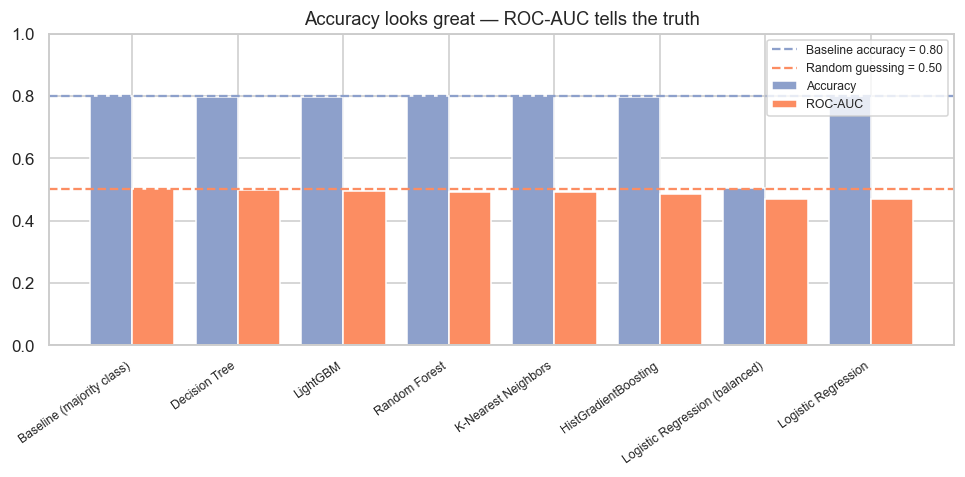

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(table))
ax.bar(x - 0.2, table["Accuracy"], 0.4, label="Accuracy", color="#8da0cb")
ax.bar(x + 0.2, table["ROC-AUC"], 0.4, label="ROC-AUC", color="#fc8d62")
ax.axhline(0.8, color="#8da0cb", ls="--", lw=1.5, label="Baseline accuracy = 0.80")
ax.axhline(0.5, color="#fc8d62", ls="--", lw=1.5, label="Random guessing = 0.50")
ax.set_xticks(x)
ax.set_xticklabels(table["Model"], rotation=35, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Accuracy looks great — ROC-AUC tells the truth")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

> ### 📌 Lesson 5 — The accuracy trap
> On imbalanced data, **accuracy is the single most misleading metric**.
> Always report it alongside **ROC-AUC, precision, recall, F1** or **balanced
> accuracy**.

---
## 6. ROC curves and the confusion matrix

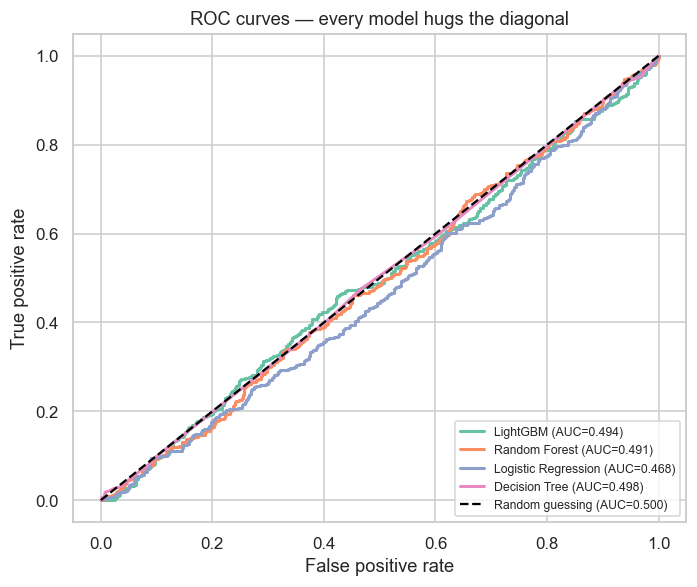

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in ["LightGBM", "Random Forest", "Logistic Regression", "Decision Tree"]:
    fpr, tpr = curves[name]
    auc = table.loc[table["Model"] == name, "ROC-AUC"].iloc[0]
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random guessing (AUC=0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — every model hugs the diagonal")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

The further an ROC curve bulges toward the **top-left**, the better the model. Here
every curve clings to the dashed diagonal — the models cannot separate sick from
healthy.

### The confusion matrix — what the errors actually cost

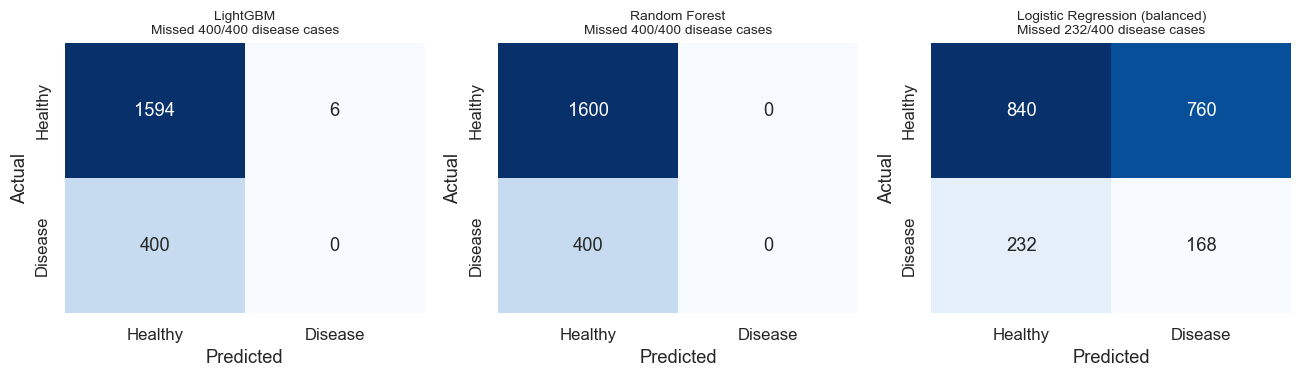

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, name in zip(axes, ["LightGBM", "Random Forest", "Logistic Regression (balanced)"]):
    cm = confusion_matrix(y_test, fitted[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Healthy", "Disease"], yticklabels=["Healthy", "Disease"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nMissed {fn}/{fn+tp} disease cases", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**The two kinds of error are not equally bad in medicine:**

- **FN (missed disease)** — the patient is sent home and may die. Severe.
- **FP (false alarm)** — the patient worries and pays for more tests. Unpleasant but
  safe.

The `class_weight="balanced"` model trades accuracy away to catch more disease cases
(higher recall). That is the right trade in a screening problem — **provided** the
model has genuine predictive power.

---
## 7. Hyperparameter tuning with `GridSearchCV`

**Hyperparameters** are the choices we make *before* training (tree depth, number of
trees, learning rate). The model does not learn them itself.

`GridSearchCV` tries **every combination** in a grid, scores each with
cross-validation, and keeps the best.

In [19]:
from sklearn.model_selection import GridSearchCV

# The "clf__" prefix routes a parameter into the Pipeline step named "clf"
grid = {
    "clf__n_estimators":     [100, 300],
    "clf__max_depth":        [4, 8, None],
    "clf__min_samples_leaf": [1, 20],
}

pipe_rf = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

n_combos = 2 * 3 * 2
print(f"{n_combos} combos x 5 folds = {n_combos * 5} fits. Running...")

search = GridSearchCV(
    pipe_rf, grid,
    scoring="roc_auc",        # never accuracy on imbalanced data!
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
search.fit(X_train, y_train)

print(f"\nBest combo: {search.best_params_}")
print(f"Best CV score: {search.best_score_:.4f}")

12 combos x 5 folds = 60 fits. Running...



Best combo: {'clf__max_depth': None, 'clf__min_samples_leaf': 20, 'clf__n_estimators': 300}
Best CV score: 0.5060


### Default versus tuned, on the **test set**

In [20]:
default = Pipeline([
    ("prep", build_preprocessor(scale=False)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

auc_default = roc_auc_score(y_test, default.predict_proba(X_test)[:, 1])
auc_tuned = roc_auc_score(y_test, search.best_estimator_.predict_proba(X_test)[:, 1])
cv_std = search.cv_results_["std_test_score"][search.best_index_]

print(f"Test ROC-AUC (default): {auc_default:.4f}")
print(f"Test ROC-AUC (tuned):   {auc_tuned:.4f}")
print(f"Change:                 {auc_tuned - auc_default:+.4f}")
print(f"\nFold-to-fold std:       +/-{cv_std:.4f}  <-- the natural noise band")

Test ROC-AUC (default): 0.5127
Test ROC-AUC (tuned):   0.4851
Change:                 -0.0275

Fold-to-fold std:       +/-0.0257  <-- the natural noise band


### 🚨 An important paradox

The **cross-validation score went up** after tuning, but the score on the **test set
did not — it fell**.

This is **overfitting to the validation set**. When you try dozens of combinations and
keep the one with the highest CV score, you are selecting the combination that got
*luckiest* with that particular fold split, not the one that is genuinely best. The
more combinations you try, the worse the problem.

Compare the "improvement" with the **±std noise band** above: the two numbers are the
same size. When a change is no larger than the natural fold-to-fold variation, there
is **no basis** for claiming the tuning helped.

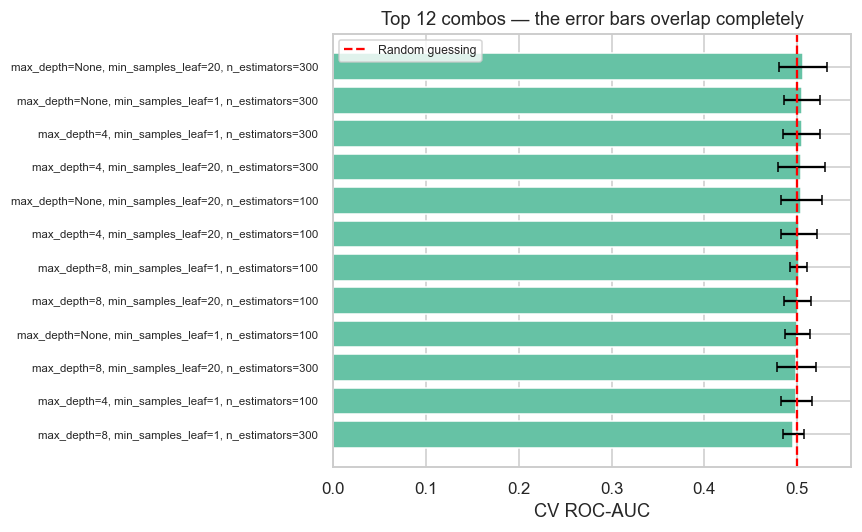

Largest train-validation gap: 0.500 (a memorisation signal)


In [21]:
res = pd.DataFrame(search.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")

fig, ax = plt.subplots(figsize=(8, 5))
top = res.head(12).iloc[::-1]
names = [", ".join(f"{k.replace('clf__','')}={v}" for k, v in p.items()) for p in top["params"]]
ax.barh(range(len(top)), top["mean_test_score"], xerr=top["std_test_score"],
        color="#66c2a5", capsize=3)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(names, fontsize=7.5)
ax.axvline(0.5, color="red", ls="--", label="Random guessing")
ax.set_xlabel("CV ROC-AUC")
ax.set_title("Top 12 combos — the error bars overlap completely")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

gap = (res["mean_train_score"] - res["mean_test_score"]).max()
print(f"Largest train-validation gap: {gap:.3f} (a memorisation signal)")

> ### 📌 Lesson 6
> - **Never report the best CV score.** Always keep a test set you have not touched
>   for the final evaluation.
> - **`GridSearchCV` must run through a `Pipeline`**, otherwise every fold leaks.
> - **Tuning only exploits signal that is already there.** It cannot conjure signal
>   out of nothing.

---
## 8. The control experiment — the decisive evidence

By now we are deeply suspicious. How do we **prove** the data has no signal, rather
than suspecting we wrote buggy code?

**The idea:** randomly shuffle all the training labels, destroying any link between
symptoms and disease, then retrain.

- If the data **does** carry signal → the score must **collapse**.
- If the data carries **no** signal → the score stays the same.

In [22]:
rng = np.random.default_rng(RANDOM_STATE)
y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

print(f"Real labels     - disease rate: {y_train.mean():.1%}")
print(f"Shuffled labels - disease rate: {y_shuffled.mean():.1%}  (unchanged, only reordered)")
print(f"Labels that moved: {(y_train.values != y_shuffled.values).sum():,} / {len(y_train):,}")

Real labels     - disease rate: 20.0%
Shuffled labels - disease rate: 20.0%  (unchanged, only reordered)
Labels that moved: 2,578 / 8,000


In [23]:
comparison = []
for name in ["Decision Tree", "Random Forest", "LightGBM", "Logistic Regression"]:
    clf, scale = next((c, s) for n, c, s in MODELS if n == name)

    real = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])
    real.fit(X_train, y_train)
    auc_real = roc_auc_score(y_test, real.predict_proba(X_test)[:, 1])

    shuf = Pipeline([("prep", build_preprocessor(scale=scale)), ("clf", clf)])
    shuf.fit(X_train, y_shuffled)
    auc_shuf = roc_auc_score(y_test, shuf.predict_proba(X_test)[:, 1])

    comparison.append({
        "Model": name,
        "ROC-AUC (REAL labels)": auc_real,
        "ROC-AUC (SHUFFLED labels)": auc_shuf,
        "Difference": auc_real - auc_shuf,
    })

ctrl = pd.DataFrame(comparison)
ctrl.round(4)

,Model,ROC-AUC (REAL labels),ROC-AUC (SHUFFLED labels),Difference
0,Decision Tree,0.4981,0.5176,-0.0195
1,Random Forest,0.4913,0.5038,-0.0125
2,LightGBM,0.4945,0.5265,-0.0320
3,Logistic Regression,0.4680,0.4945,-0.0266


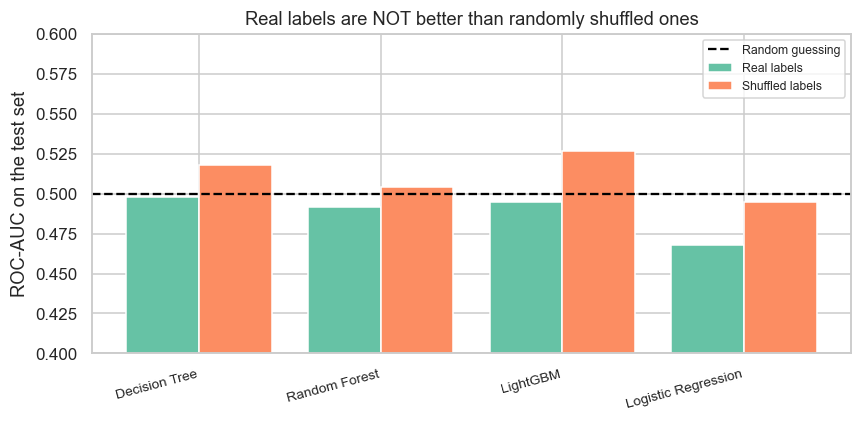

Mean difference: -0.0226
(if the data carried signal this would be LARGE and clearly POSITIVE)


In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ctrl))
ax.bar(x - 0.2, ctrl["ROC-AUC (REAL labels)"], 0.4, label="Real labels", color="#66c2a5")
ax.bar(x + 0.2, ctrl["ROC-AUC (SHUFFLED labels)"], 0.4, label="Shuffled labels", color="#fc8d62")
ax.axhline(0.5, color="black", ls="--", lw=1.5, label="Random guessing")
ax.set_xticks(x)
ax.set_xticklabels(ctrl["Model"], rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.4, 0.6)
ax.set_ylabel("ROC-AUC on the test set")
ax.set_title("Real labels are NOT better than randomly shuffled ones")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Mean difference: {ctrl['Difference'].mean():+.4f}")
print("(if the data carried signal this would be LARGE and clearly POSITIVE)")

### ✅ The verdict

**Training on random labels scores as well as — sometimes better than — training on
the real ones.**

The models learned no relationship whatsoever between features and disease. Every
small difference is random noise.

This dataset is **randomly generated synthetic data**; the input features are
statistically independent of the label.

> ### 📌 Lesson 7 — The control experiment
> Make this a **standing habit** in every ML project. It catches both fatal failures:
> - **Useless data** (this case): shuffled labels score as well as real ones.
> - **Data leakage**: scores are suspiciously high in *both* conditions.

---
## 9. Conclusions

### The seven lessons

| # | Lesson |
|---|---|
| 1 | Always reconcile the data against the data dictionary — `"None"` nearly cost us 25% of a column |
| 2 | Do not `dropna()` reflexively; a bad read inflated the missing rate from 5.0% to 29.3% |
| 3 | Wrap every step in a `Pipeline` to prevent data leakage |
| 4 | Always build a baseline — without a floor you cannot judge a model |
| 5 | Accuracy lies on imbalanced data — 80% here means doing nothing |
| 6 | Never report the best CV score; it is already overfit to the validation folds |
| 7 | Always run the shuffled-label control experiment |

### The message that matters most

> A **carefully demonstrated ROC-AUC of 0.5** is a **correct and scientifically
> valuable** result.
>
> Being able to stop and say *"this data cannot answer the question"* is a
> **professional skill**, not a failure.
>
> The real mistake is forcing a model to produce a flattering number and then
> reporting it — in medicine, that can get patients sent home with a disease.

Strong models cannot rescue weak data. LightGBM, Random Forest and boosting all lose
here, because **no algorithm can manufacture information the data does not contain**.

---
## 🎓 Exercises

**1 — The decision threshold.**
By default the classifier says "disease" when the probability exceeds 0.5. Try
lowering it to 0.3 and 0.2. How do precision, recall and F1 move? In medical
screening, which threshold would you pick, and why?

```python
y_proba = fitted["LightGBM"].predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.3, 0.2, 0.15]:
    y_pred = (y_proba > threshold).astype(int)
    # compute precision, recall, f1 here
```

**2 — Simulate data that DOES have signal.**
Use `sklearn.datasets.make_classification` to build a 10,000-row, 20-feature set with
`weights=[0.8, 0.2]` but `n_informative=6`. Run the whole workflow again. What
ROC-AUC do you get? How does the ROC curve look different?

**3 — Create data leakage on purpose.**
Deliberately do it wrong: impute and scale the **entire** `X` *before* the train/test
split. How do the scores change? Why is this such a dangerous bug?

**4 — Add a feature that genuinely carries signal.**
Create `X["cheat"] = y * 0.8 + random noise`. Retrain. How far does ROC-AUC jump? Which
real-world form of data leakage does this illustrate?

**5 — Find a real dataset.**
Download the *UCI Heart Disease* set (303 rows of genuine clinical data) and rerun this
notebook on it. Compare the ROC-AUC with what you saw here. What do you conclude?